In [1]:
import merlin_spectra
from merlin_spectra.emission import EmissionLineInterpolator

import os
import copy

import numpy as np
from numpy import ndarray
import yt
from yt.frontends.ramses.field_handlers import RTFieldFileHandler

import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.constants import c

In [2]:
full_lum = [3.90955858e+41, 3.31949205e+36, 2.26410702e+34, 2.72101305e+36,
 1.20475976e+37, 2.26032755e+37, 8.64213222e+35, 2.53087718e+36,
 9.26514983e+35, 8.30460881e+36, 1.03474205e+42, 4.13492301e+33,
 4.83716059e+35, 1.49603706e+37, 1.26528935e+37, 4.24149818e+29,
 2.19186638e+37, 1.10545778e+37, 5.37404641e+35, 1.63110992e+35,
 6.97985519e+32, 3.48213989e+32, 1.58560762e+33, 1.32286373e+36,
 2.66617959e+36]

wavelengths=np.array([6562.80, 1304.86, 6300.30, 3728.80, 3726.10, 1660.81, 1666.15,
             4363.21, 4958.91, 5006.84, 1640.41, 1335.66,
             1906.68, 1908.73, 1549.00, 2795.53, 2802.71, 3868.76,
             3967.47, 1238.82, 1242.80, 1486.50, 1749.67, 6716.44, 6730.82])

### Function Definition (Need more comments) ###
def ergcm2s_to_jyhz(F_erg_cm2_s):
    # 1 erg/s/cm^2 = 1e23 Jy Hz

    return F_erg_cm2_s * 1e23 * u.Jansky

def gaussian_spectrum_from_integrated_flux_erg(
    lambda_array: ndarray,          # wavelength grid (Å)
    line_cents_array: ndarray,      # line centers (Å)
    sigma_v_kms: ndarray,           # Gaussian sigma in km/s (scalar or array)
    F_line_erg_cm2_s: ndarray       # assuming integrated fluxes are in correct unit: (erg/s/cm^2), array 
) -> u.uJy:
    """
    Returns the combined line spectrum S(λ) in Jy.
    Gaussian profile defined in frequency domain but evaluated on λ grid.
    """

    # ---- Convert inputs to arrays ----
    lambda_array = np.asarray(lambda_array, float)        # (Nλ,)
    line_cents_array = np.asarray(line_cents_array, float)  # (Nlines,)
    sigma_v_kms = np.asarray(sigma_v_kms, float)            # scalar or (Nlines,)
    F_line_erg_cm2_s = np.asarray(F_line_erg_cm2_s, float)  # (Nlines,)

    # ---- Convert wavelength to frequency ----
    # Å → cm
    lam_cm = lambda_array * 1e-8
    lam0_cm = line_cents_array * 1e-8

    # λ → ν conversion
    nu_array = c.cgs.to_value() / lam_cm         # Hz, shape (Nλ,)
    nu0 = c.cgs.to_value()  / lam0_cm             # Hz, shape (Nlines,)

    # ---- Convert integrated flux to (Jy Hz) ----
    F_jyhz = ergcm2s_to_jyhz(F_line_erg_cm2_s)  # shape (Nlines,)

    # ---- Convert sigma_v → sigma_nu ---- # frankly don't know how this works
    sigma_nu = (nu0 / 2.99792458e5) * sigma_v_kms   # km/s to Hz

    # ---- Gaussian amplitude in Jy ----
    A_jy = F_jyhz / (sigma_nu * np.sqrt(2*np.pi))

    # ---- Broadcast Gaussian calculation ----
    # nu_array: (Nλ,) → (1, Nλ)
    # nu0:      (Nlines,) → (Nlines, 1)
    nu_diff = nu_array[None, :] - nu0[:, None]

    S_each = A_jy[:, None] * np.exp(-0.5 * (nu_diff / sigma_nu[:, None])**2)

    # ---- Sum over all lines ----
    S_total = np.sum(S_each, axis=0)

    return S_total.to(u.uJy)



50.0
590.0 246.57504671551607 3.3770768900368466
530.0 186.57504671551607 -56.62292310996315
nbins= 400
CC [5535710.5] [8.768885]
CC [5535710.5] [8.768885]
low [2189732.4]
high [1359736.3]
Mag = -14.000000 -> Solar masses (10Myr): 2.381983e+05
90.97139024581668 Angstrom 1399559.849935641 Angstrom
0.006937468138491545 uJy


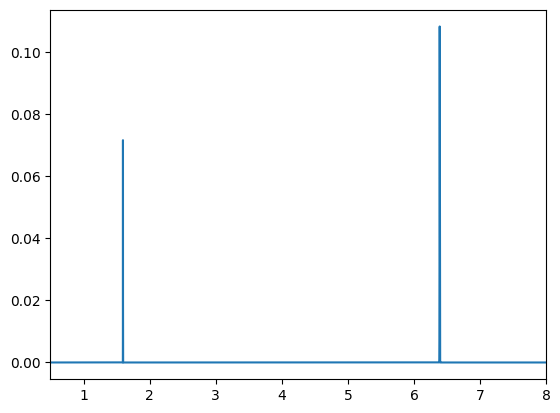

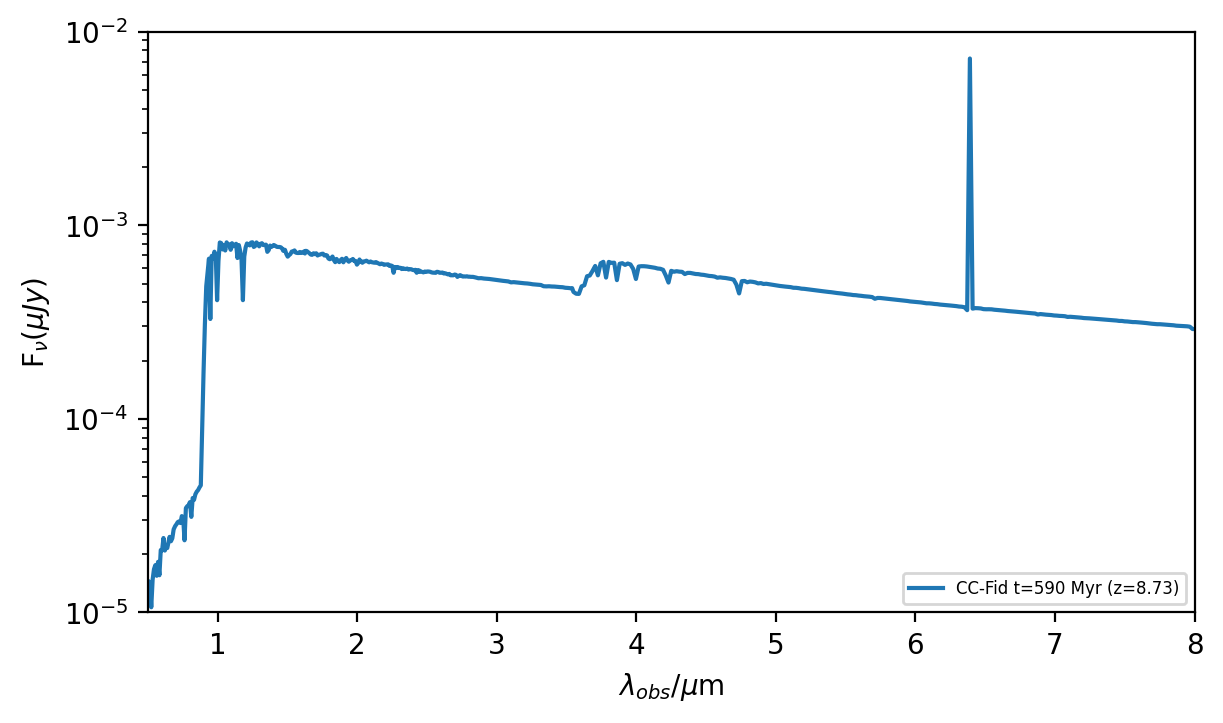

In [3]:
from sed_continuum import sed_cont

z_test = 8.73  # source redshift
cosmo = FlatLambdaCDM(H0=70 * u.km/u.s/u.Mpc, Om0=0.3)
D_L = cosmo.luminosity_distance(z_test).to(u.cm).value
F_values = full_lum / (4 * np.pi * D_L**2)  # erg/s/cm^2

wav_obs0, wav_obs1, a1, b1, y_tot0, y_tot1, run, time0, time1, redsh0, redsh1, ti, sfri, Hredshift, Htime, zs, masses = sed_cont()
wav_obs0u = np.array(wav_obs0[a1:b1]) * u.micron
wav_obs1u = np.array(wav_obs1[a1:b1]) * u.micron
wav_rf = wav_obs0u.to(u.Angstrom)/(1+z_test)
print(min(wav_rf), max(wav_rf))
out0 = gaussian_spectrum_from_integrated_flux_erg(wav_rf.value, wavelengths, 100, F_values)

testx = np.linspace(200,10000,200000) * u.Angstrom

testspec = gaussian_spectrum_from_integrated_flux_erg(testx.value, wavelengths, 100, F_values)
testx_mic = (testx * (1+z_test)).to(u.micron)

### troubleshooting
print(np.max(out0))
#plt.plot(wav_rf, out0)
plt.plot(testx_mic, testspec)
plt.xlim(0.5, 8)
plt.show()

#gaussian_spectrum_from_integrated_flux_erg(wav_obs0, )
fig, axs = plt.subplots(1,1, figsize = (6,3.5), dpi = 200, constrained_layout = True)
axs.plot(wav_obs0[a1:b1], y_tot0+out0.value, label=f'{run:s} t={time0:3.0f} Myr (z={redsh0:2.2f})')
axs.set_yscale('log')
#axs.set_yscale('linear')
axs.set_xlim(0.5, 8)
#axs.set_ylim(1e-25,1e-20)
axs.set_ylim(1e-5,1e-2)
axs.set_xlabel(r"$\lambda_{obs}/\mu$m")
#axs.set_ylabel(r"F$_\lambda(erg/s/cm^2/A)$")
axs.set_ylabel(r"F$_\nu(\mu Jy)$")
axs.legend(fontsize="6", loc ="lower right")

0.08851516270917964 0.0917816162109375 0.019453881914105686
Simulated 4657 NIRSpec pixels from 0.09 micron to 700.19 micron μm


(0.5, 8.0)

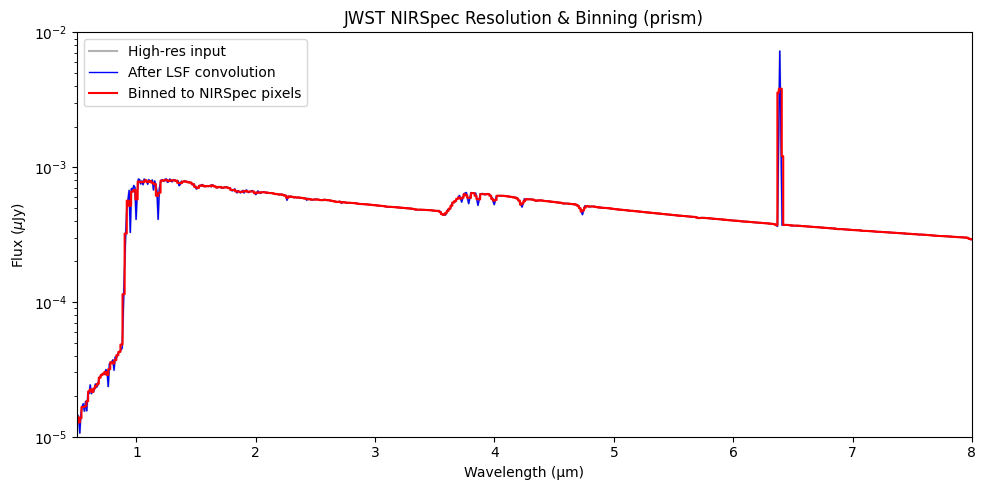

In [9]:
from Fitser_v2 import JWST_disperser
prism = JWST_disperser("prism")

prism.binner(flux_in = y_tot0+out0.value, wave_in = wav_obs0[a1:b1])
plt.yscale("log")
plt.ylim(10**-5, 10**-2)
plt.xlim(0.5,8)